### Lectura de tickets
El objetivo es generar un programa que "lea" una foto de un ticket/factura realizada para la empresa 
y tome los datos de interes como:
- Nombre de empresa
- CUIT
- Fecha
- Nro de comprobante
- Monto
- Impuestos

OCR significa Optical Character Recognition, es decir, Reconocimiento Óptico de Caracteres

In [1]:
#Librerias
import re
import os
from pathlib import Path
import cv2
import pytesseract
import pandas as pd
import matplotlib.pyplot as plt
print("libreria ok")

libreria ok


### Configuraciones previas

In [2]:
# Ruta donde esta instalado localmente Tesseract OCR
pytesseract.pytesseract.tesseract_cmd = ("C:/Program Files/Tesseract-OCR/tesseract.exe")
#Vemos si la configuracion esta en español o no
print(pytesseract.get_languages(config=""))

['osd', 'spa']


In [3]:
# Carpeta donde están las imagenes
CARPETA_FACTURAS = Path("D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/tickets/imagenes")
CARPETA_FACTURAS

WindowsPath('D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/tickets/imagenes')

In [4]:
# Carpeta de salida
CARPETA_RESULTADOS = Path("D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/tickets/resultados")
# Crear carpeta de resultados si no existe
# CARPETA_RESULTADOS.mkdir(exist_ok=True)

# No se usa esto en esta etapa

In [5]:
# Como son mas o menos las mismas empresas de tikets las dejamos nombradas
EMPRESAS_CONOCIDAS = {
    "30-61415063-3": "LUCAM S.A",
    "30-68760432-2": "NELSO S A",
    "30-71691301-1": "Oil Petro Salsipuedes S.A."
}

# Datos de la empresa propia
# Este CUIT puede aparecer en las facturas como receptor.
# No queremos confundirlo con el CUIT del proveedor.
CUIT_PROPIO = "30-71543101-3"

### Funcion principal

In [6]:

# 1. Cargar imagen
def cargar_imagen(ruta_imagen):
    """
    Carga una imagen desde una ruta.
    """
    imagen = cv2.imread(str(ruta_imagen))
    if imagen is None:
        raise ValueError(f"No se pudo cargar la imagen: {ruta_imagen}")
    return imagen

# 2. Mejorar la imagen cargada
def mejorar_imagen(imagen):
    """
    Mejora la imagen para facilitar la lectura del OCR.
    """
    # Convertir a escala de grises
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    # Aumentar el tamaño de la imagen
    # gris = cv2.resize(gris, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    # Reducir ruido
    #gris = cv2.GaussianBlur(gris, (3, 3), 0)
    # Convertir a blanco y negro
    #imagen_mejorada = cv2.threshold( gris,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU )[1]

    #1era mejora imagen
    # Aumentar resolución
    gris = cv2.resize(gris, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    imagen_mejorada = cv2.normalize(gris, None, 0, 255, cv2.NORM_MINMAX)

    # Mostrar imagen mejorada
    plt.figure(figsize=(12, 16)) 
    plt.imshow(imagen_mejorada, cmap="gray")
    plt.axis("off")
    plt.show()
    return imagen_mejorada


# 3. Uso del OCR para generar la imagen
def obtener_texto(imagen):
    """
    Ejecuta OCR sobre una imagen.
    """
    texto = pytesseract.image_to_string(imagen, lang="spa")

    return texto

# 3. Limpiar el texto que genero el OCR
def limpiar_texto(texto):
    """
    Limpia espacios y saltos de línea innecesarios.
    """
    # Normalizar saltos de línea
    texto = texto.replace("\r\n", "\n")

    # Reducir multiples saltos de línea
    texto = re.sub(r"\n{2,}", "\n", texto)

    # Reducir multiples espacios
    texto = re.sub(r"[ \t]+", " ", texto)
    return texto.strip()


# 4. extraer solo cuit de interes
def extraer_cuit(texto):
    """
    Busca todos los CUIT encontrados en el texto.
    Luego descarta el CUIT propio de Isla
    """
    patrones = [
        r"\b\d{2}-\d{8}-\d\b",
        r"\b\d{2}\s*-\s*\d{8}\s*-\s*\d\b",
        r"\b\d{2}\s+\d{8}\s+\d\b",
        r"\b\d{2}[\s-]*\d{8}[\s-]*\d\b" ]

    cuit_encontrados = []
    # Buscar todos los CUIT
    for patron in patrones:

        resultados = re.findall( patron, texto)
        cuit_encontrados.extend(resultados)
    cuit_normalizados = []

    for cuit in cuit_encontrados:
        # Eliminar espacios
        cuit = re.sub(r"\s+","",cuit)
        # Si no tiene guiones,
        # agregar formato XX-XXXXXXXX-X
        if "-" not in cuit:
            cuit = (cuit[:2]+ "-" + cuit[2:10] + "-" + cuit[10:])
        # Evitar duplicados
        if cuit not in cuit_normalizados:
            cuit_normalizados.append(cuit)

    # Eliminar el CUIT propio
    cuit_proveedores = [cuit for cuit in cuit_normalizados if cuit != CUIT_PROPIO]

    # Devolver el primer CUIT restante
    if cuit_proveedores:
        return cuit_proveedores[0]
    return None


# 5. Identificar la empresa 
def identificar_empresa(cuit):
    """
    Busca el nombre de la empresa utilizando el CUIT.
    """
    if cuit in EMPRESAS_CONOCIDAS:
        return EMPRESAS_CONOCIDAS[cuit]
    return "EMPRESA NO IDENTIFICADA"

# 6. Extraer fecha

def extraer_fecha(texto):
    """
    Extrae la fecha de emisión.
    Primero busca fechas asociadas a:
    - FECHA
    - FECHA DE EMISIÓN
    - FECHA EMISIÓN
    Evita tomar: INICIO DE ACTIVIDADES
    """
    # Buscar fecha de emisión
    patrones_fecha_emision = [
        r"(?:FECHA\s+DE\s+EMISI[ÓO]N|"
        r"FECHA\s+EMISI[ÓO]N|FECHA)"
        r"\s*:?\s*"
        r"(\d{2}[\/\-\.]\d{2}[\/\-\.]\d{4})",
    ]

    for patron in patrones_fecha_emision:
        resultado = re.search(patron, texto, re.IGNORECASE) #re.IGNORECASE hace que no importe si el OCR lee FECHA/fecha/Fecha
        if resultado:
            fecha = resultado.group(1)
            # Normalizar separadores
            fecha = fecha.replace("-","/")
            fecha = fecha.replace(".","/")
            return fecha

    # Buscar todas las fechas
    patrones_generales = [
        r"\b\d{2}/\d{2}/\d{4}\b",
        r"\b\d{2}-\d{2}-\d{4}\b",
        r"\b\d{2}\.\d{2}\.\d{4}\b",
    ]

    fechas_encontradas = []
    for patron in patrones_generales:
        resultados = re.findall(patron, texto)
        fechas_encontradas.extend(resultados)

    # Eliminar fechas de inicio de actividades
    fechas_validas = []
    for fecha in fechas_encontradas:
        posicion_fecha = texto.find(fecha)
        texto_cercano = texto[max(0, posicion_fecha - 80):posicion_fecha + 80]

        if re.search(r"INICIO\s+DE\s+ACTIVIDADES", texto_cercano, re.IGNORECASE):
            continue
        fechas_validas.append(fecha)

    if fechas_validas:
        fecha = fechas_validas[0]
        fecha = fecha.replace("-","/")
        fecha = fecha.replace( ".","/")
        return fecha
    return None


# 7. Convertir montos
#Esta funcion se usa en las que vienen a continuacion
def convertir_monto(texto_monto):
    """
    Convierte formatos argentinos como:
    $125.450,00; 125.450,00; 125450,00
    en formatos listos para trabajar como: 125450.00
    """
    if texto_monto is None:
        return None
    monto = texto_monto.strip()
    # Eliminar símbolo $
    monto = monto.replace("$", "")
    # Eliminar espacios
    monto = monto.replace(" ", "")
    # Formato argentino: 125.450,00 / 125450.00

    if "." in monto and "," in monto:
        monto = monto.replace( ".", "")
        monto = monto.replace(",", ".")

    # Formato: 125450,00
    elif "," in monto:
        monto = monto.replace(",", ".")
    try: 
        return float(monto)

    except ValueError:
        return None


# 8. Extraer neto gravado 
def extraer_neto_gravado(texto):
    """
    Busca el importe asociado a: Neto Gravado / Neto gravado
    """
    patrones = [
        r"Neto\s+Gravado"
        r"\s*:?\s*\$?\s*"
        r"([\d.,]+)",
    ]

    for patron in patrones:
        resultado = re.search(patron, texto, re.IGNORECASE)
        if resultado:
            monto_texto = resultado.group(1)
            return convertir_monto(monto_texto)
    return 0

# 9. Extraer IVA
# Puede ser que haya otros IVA 27%, 3% por ahora no los consideramos, solo 21%
def extraer_iva(texto):
    """
    Busca el importe correspondiente al IVA 21%.
    """
    patrones = [

        # IVA 21%
        r"IVA\s*21\s*%\s*:?\s*\$?\s*([\d.,]+)",

        # I.V.A. 21%
        r"I\.V\.A\.\s*21\s*%\s*:?\s*\$?\s*([\d.,]+)",

        # ALICUOTA 21,00% o 21.00%
        r"AL[IÍ]CUOTA\s*21[.,]00\s*%\s*:?\s*\$?\s*([\d.,]+)",

        # I.V.A. seguido directamente del importe
        r"I\.V\.A\.\s*:?\s*\$?\s*([\d.,]+)",

    ]
    for patron in patrones:
        resultado = re.search(patron, texto,re.IGNORECASE)
        if resultado:
            monto_texto = resultado.group(1)
            return convertir_monto(monto_texto)
    return None # 0



# 10. Extraer otros conceptos no gravados 
# Esto es para los tickets de combustibles
def extraer_otros_conceptos(texto):
    """
    Busca conceptos adicionales como:
    Conceptos no gravados
    Importe total otros atributos
    Si no aparecen, devuelve 0.
    """

    patrones = [
        r"CONCEPTOS\s+NO\s+GRAVADOS\s*:?\s*\$?\s*([\d.,]+)",

        r"IMPORTE\s+TOTAL\s+OTROS\s+ATRIBUTOS\s*:?\s*\$?\s*([\d.,]+)",

        r"IMPORTE\s+TOTAL\s+OTROS\s+TRIBUTOS\s*:?\s*\$?\s*([\d.,]+)",
    ]

    for patron in patrones:
        resultado = re.search(patron, texto,re.IGNORECASE)
        if resultado:
            monto_texto = resultado.group(1)
            return convertir_monto(monto_texto)
    return 0


# 11. Extraer el total de la factura
def extraer_total_factura(texto):
    """
    Busca el total final informado en la factura.

    Ejemplos: 
    Importe Total: $125.450,00
    Total a pagar: $125.450,00
    Total: $125.450,00
    TOTAL: $125.450,00
    """
    patrones = [

        # IMPORTE TOTAL
        r"IMPORTE\s+TOTAL.*?(\d[\d.,]*)",

        # TOTAL A PAGAR
        r"TOTAL\s+A\s+PAGAR.*?(\d[\d.,]*)",

        # TOTAL .... 19998.13
        r"\bTOTAL\b.*?(\d[\d.,]*)",

    ]

    for patron in patrones:
        resultado = re.search(patron, texto,re.IGNORECASE )
        if resultado:
            monto_texto = resultado.group(1)
            return convertir_monto(monto_texto)

    return None #0


# 12. Extraer y validar todos valores de importes anteriores

def extraer_importes(texto):

    neto_gravado = extraer_neto_gravado(texto)
    iva = extraer_iva(texto)
    if iva is None and neto_gravado is not None:
        iva = round(neto_gravado * 0.21, 2)
    otros_conceptos = extraer_otros_conceptos(texto)
    total_extraido = extraer_total_factura(texto)
    total_calculado = round((neto_gravado or 0) + (iva or 0) + (otros_conceptos or 0), 2 )

    if total_extraido is not None:
        diferencia = round(total_calculado - total_extraido, 2)
        if abs(diferencia) < 0.01:
            validacion = "OK"
        else:
            validacion = "Revisar!!"
        total_final = total_extraido
    else:
        diferencia = None
        validacion = "Total calculado"
        total_final = total_calculado
    return {
        "neto_gravado": neto_gravado,
        "iva": iva,
        "otros_conceptos": otros_conceptos,
        "total_calculado": total_calculado,
        "total_factura": total_extraido,
        "total_final": total_final,
        "diferencia": diferencia,
        "validacion": validacion,
    }



# 13. Extraer numero de factura
def extraer_numero_factura(texto):
    patrones = [

        r"\b\d{4}-\d{8}\b",
        r"\b\d{4}\s*-\s*\d{8}\b",
        r"\b\d{4}/\d{8}\b",
    ]

    for patron in patrones:
        resultado = re.search(patron,  texto)
        if resultado:
            numero = resultado.group()
            # Eliminar espacios
            numero = numero.replace( " ", "")
            # Normalizar separador
            numero = numero.replace("/","-")
            return numero
    return None



# 14. Procesar una factura entera 
# Unimos todas las funciones anteriores y se obtiene como salida un df con toda la info de interes
def procesar_factura(ruta_imagen):
    # Cargar imagen
    imagen = cargar_imagen(ruta_imagen)
    # Mejorar imagen
    imagen_mejorada = mejorar_imagen(imagen)
    # OCR
    texto = obtener_texto(imagen_mejorada)
    # Limpiar texto
    texto = limpiar_texto(texto)
    # Extraer datos generales de la factura
    cuit = extraer_cuit(texto)
    empresa = identificar_empresa(cuit)

    print("CUIT DENTRO DE procesar_factura:")
    print(repr(cuit))

    print("EMPRESA DENTRO DE procesar_factura:")
    print(repr(empresa))

    fecha = extraer_fecha(texto)
    numero_factura = extraer_numero_factura(texto)
    # Extraer valores de los importes
    importes = extraer_importes(texto)
    # Crear DataFrame final
    df = pd.DataFrame([{
        "Fecha": fecha,
        "Numero Comprobante": numero_factura,
        "Razon Social": empresa,
        "Cuit": cuit,
        "Neto Gravado": importes["neto_gravado"],
        "Iva % 21": importes["iva"],
        "Otros conceptos": importes["otros_conceptos"],
        #"Total": importes["total_factura"],
        "Total": importes["total_final"],
    }])

    return df




### Pruebas individuales de funciones 

In [118]:
##  Pruebas individuales de funciones 


ruta_imagen = ("D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/tickets/imagenes/LUCAM.jpeg")

# 1. Cargar imagen
imagen = cargar_imagen(ruta_imagen)
#print(imagen)

# 2. Mejorar imagen
# Esto sirve para ver realmente si se ven todos los datos o no
# imagen_mejorada = mejorar_imagen(imagen)

# 3. Ejecutar OCR
#Muestra el texto que se pudo rescatar de la imagen
texto = obtener_texto(imagen)
# print(texto)

# 4. Limpiar texto
texto_limpio = limpiar_texto(texto)
print(texto_limpio)
texto_limpio

1S.A Ci reunvalac
CuIT: 30-61415063-3
resos Brutos: 200969081 *
Circunvalacion esq capdev Es
24- 04 -2020
Inicio Actividad:
RESPONSABLE INSCRIPTO
O ORIGINAIL
— RA A (001)
Ed
Nro.: 0093-00008225
Fecha 01/07/2026 11 34 00
c11ente. 33204 ISLA ECOLOGICA S
A
Dir:
Loc: Sin Localidad-SIN PROVINCIA
cpo: 0
| CUIT: 30-71543101-3
RESPONSABLE 1NS/¡LPTO
CANTIDAD X PRECIO UNITARIO
PRECIO NETO
DESCRIPCION
8,8370 x 2263,00
DIESEL 5O0 as 14528,1?
Neto Gravado 14528,12
I.V.A. 3050,91
Conceptos No Gravados 2419,10
*'““'_…"í5555”í5**
Planilla: 00011775
operario: SANTILLAN NICOLAS


'1S.A Ci reunvalac\nCuIT: 30-61415063-3\nresos Brutos: 200969081 *\nCircunvalacion esq capdev Es\n24- 04 -2020\nInicio Actividad:\nRESPONSABLE INSCRIPTO\nO ORIGINAIL\n— RA A (001)\nEd\nNro.: 0093-00008225\nFecha 01/07/2026 11 34 00\nc11ente. 33204 ISLA ECOLOGICA S\nA\nDir:\nLoc: Sin Localidad-SIN PROVINCIA\ncpo: 0\n| CUIT: 30-71543101-3\nRESPONSABLE 1NS/¡LPTO\nCANTIDAD X PRECIO UNITARIO\nPRECIO NETO\nDESCRIPCION\n8,8370 x 2263,00\nDIESEL 5O0 as 14528,1?\nNeto Gravado 14528,12\nI.V.A. 3050,91\nConceptos No Gravados 2419,10\n*\'““\'_…"í5555”í5**\nPlanilla: 00011775\noperario: SANTILLAN NICOLAS'

In [134]:
# # 5. Extraer cuit
# texto_prueba = "CuIT: 30-61415063-3"

# print(extraer_cuit(texto_prueba))
# # otra prueba
# texto_prueba = """
# FACTURA A
# CUIT: 30-61415063-3
# CUIT: 30-71543101-3
# """
# texto_prueba = """
# CUIT: 30-71543101-3
# """

# resultado = extraer_cuit(texto_prueba)

# print("CUIT encontrado:", resultado)

# CUIT obtenido por la función anterior

cuit = extraer_cuit(texto)
print(cuit)

# 5. Identificar empresa
empresa = identificar_empresa(cuit)
print(empresa)

cuit = extraer_cuit(texto)

print("CUIT EXTRAÍDO:")
print(repr(cuit))


None
EMPRESA NO IDENTIFICADA
CUIT EXTRAÍDO:
None


In [131]:
texto = obtener_texto(imagen_mejorada)

print("\nCUIT ANTES DE LIMPIAR:")

for linea in texto.splitlines():

    if "CUIT" in linea.upper():

        print(repr(linea))


texto = limpiar_texto(texto)

print("\nCUIT DESPUÉS DE LIMPIAR:")

for linea in texto.splitlines():

    if "CUIT" in linea.upper():

        print(repr(linea))


cuit = extraer_cuit(texto)


CUIT ANTES DE LIMPIAR:
'CUIT: 30-71543101-3'

CUIT DESPUÉS DE LIMPIAR:
'CUIT: 30-71543101-3'


In [ ]:
# 6. Extraer fecha
texto_prueba = """ INICIO DE ACTIVIDADES: 15/03/2018, FECHA: 01/07/2026"""
texto_prueba = "FECHA: 05/07/2026"
texto_prueba = "FECHA: 09-07-2026"
texto_prueba = "10-07-2026"
texto_prueba = """ INICIO DE ACTIVIDADES: 15/03/2018"""
fecha = extraer_fecha(texto_prueba)
print(fecha)

fecha2 = extraer_fecha(texto)
print(fecha2)

None
01/07/2026


In [42]:
# 7. Funcion de convertir formato del monto
print(convertir_monto("$125.450,00"))
print(convertir_monto("125.450,00"))

125450.0
125450.0


In [ ]:
# 8. Buscar el neto gravado
texto_prueba = """
FACTURA A
NETO GRAVADO: 1111
IVA 21%: 3.33
TOTAL: 17.579,03
"""
resultado = extraer_neto_gravado(texto_prueba)
print(resultado)

#Real
neto = extraer_neto_gravado(texto)
print(neto)
# print(texto)

1111.0
14528.12


In [68]:
# 9. Extraer IVA
# IVA 21%: 2.050,91
# IVA 3%: 3.050,91
#IVA: 3.050,91
# "I.V.A. 21%: $3.050,91",
texto_prueba = """
FACTURA A
Neto Gravado: 14.528,12
ALICUOTA 21,00%: 3.050,91

TOTAL: 17.579,03
"""
iva = extraer_iva(texto_prueba)
#print(iva)

#print(texto)
# Real
iva2 = extraer_iva(texto)
print(iva2)


3050.91


In [75]:
# 10. Extraer otros conceptos no gravados 
# CONCEPTOS NO GRAVADOS: 2.500,00
# IMPORTE TOTAL OTROS ATRIBUTOS: 1.500,00
texto_prueba = """
FACTURA DE COMBUSTIBLE
NETO GRAVADO: 50.000,00
IVA 21%: 10.500,00

TOTAL: 63.000,00
"""
otros = extraer_otros_conceptos(texto_prueba)
print(otros)

#Real
otros2 = extraer_otros_conceptos(texto)
print(otros2)

0
2419.1


In [101]:
# 11. Extraer el total de la factura
#TOTAL: 121.000,00
#IMPORTE TOTAL: $125.450,00
# texto_prueba = """
# FACTURA A
# NETO GRAVADO: 100.000,00
# IVA 21%: 21.000,00
# TOTAL ....... 124.450,00
# """

# total = extraer_total_factura(texto_prueba)
# # print(total)

# total2 = extraer_total_factura(texto)
# print(total2)


# texto_prueba = "TOTAL .... 19998.13"
# patron = r"TOTAL.*?([\d.,]+)"
# resultado = re.search(patron,texto_prueba,re.IGNORECASE)
# print(resultado.group(1))

# texto_prueba = "TOTAL .... 19998.13"
# patron = r"TOTAL.*?(\d[\d.,]*)"
# resultado = re.search(patron,texto_prueba,re.IGNORECASE)
# print(resultado.group(1))

texto_prueba = "TOTAL ....... 124450,00"

patron = r"TOTAL.*?(\d[\d.,]*)"

resultado = re.search(patron, texto_prueba,re.IGNORECASE)

print(resultado.group(1))

124450,00


In [116]:
# 12. Extraer y validar todos valores de importes anteriores
# I.V.A. 3050,91
texto_prueba = """
Neto Gravado 14528,12

Conceptos No Gravados 2419,10
TOTAL ....... 19998,13
"""
resultado = extraer_importes(texto_prueba)
resultado

{'neto_gravado': 14528.12,
 'iva': 3050.9052,
 'otros_conceptos': 2419.1,
 'total_calculado': 19998.1252,
 'total_factura': 19998.13,
 'diferencia': -0.00480000000243308,
 'validacion': 'OK'}

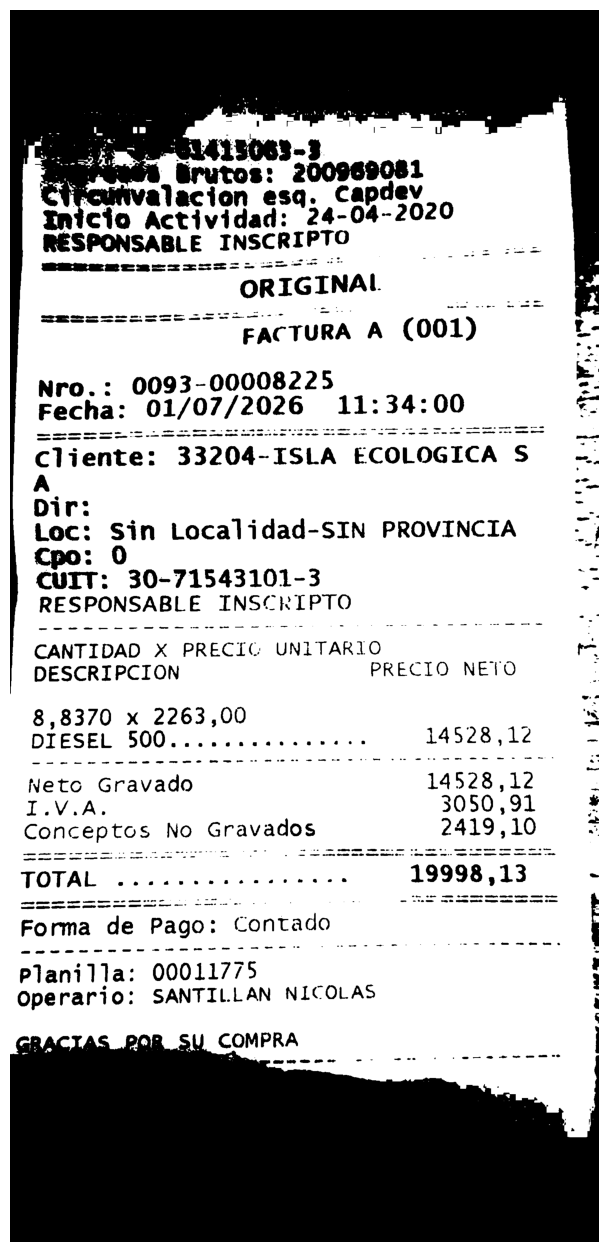

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 16))

plt.imshow(
    imagen_mejorada,
    cmap="gray"
)

plt.axis("off")

plt.show()

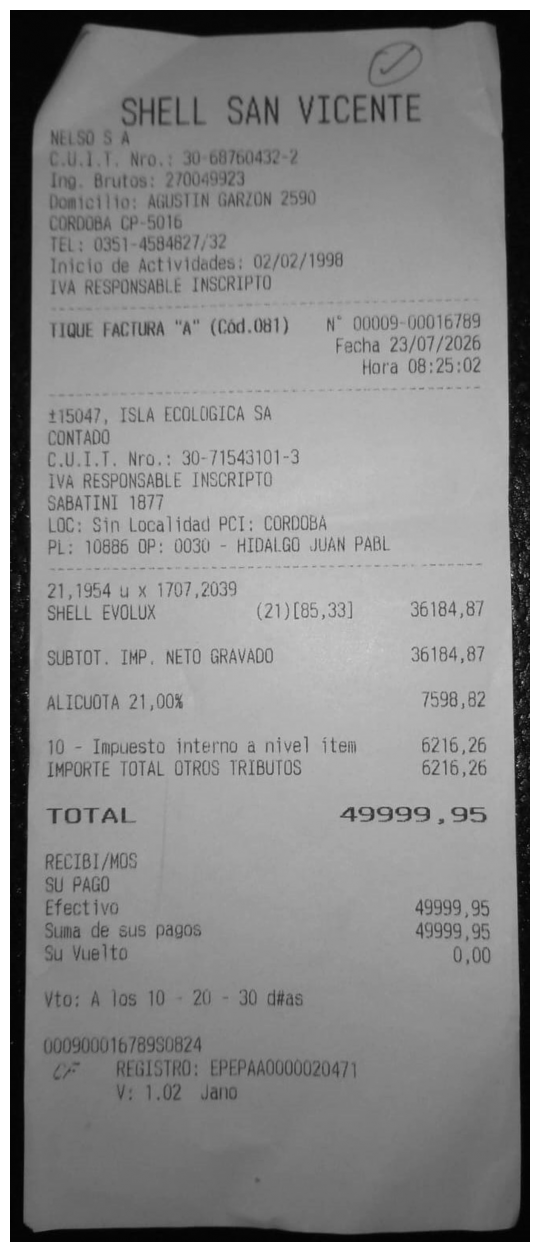

CUIT DENTRO DE procesar_factura:
None
EMPRESA DENTRO DE procesar_factura:
'EMPRESA NO IDENTIFICADA'
  Fecha Numero Comprobante             Razon Social  Cuit  Neto Gravado  \
0  None               None  EMPRESA NO IDENTIFICADA  None             0   

   Iva % 21  Otros conceptos    Total  
0       0.0          6216.26  6216.26  


In [148]:
# Ejecturar todo el programa 
if __name__ == "__main__":

    imagen = ("D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/tickets/imagenes/shell_sanVicente.jpeg")
    df = procesar_factura(imagen)
    print(df)

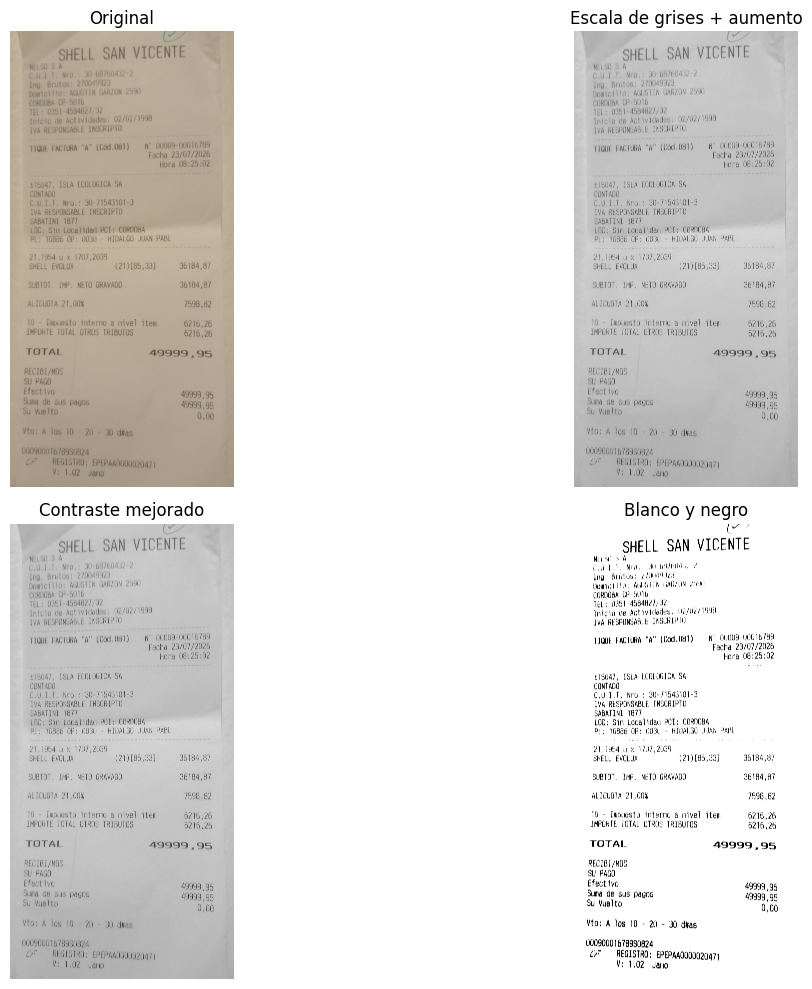

In [7]:
# Se prueban algunas mejoras del procesamiento de la imagen
def probar_preprocesamiento(imagen):

    # Imagen original
    original = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    # Version 1: ESCALA DE GRISES + AUMENTO
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    gris = cv2.resize(gris, None, fx=3,fy=3, interpolation=cv2.INTER_CUBIC)

    # Version 2: Contraste
    contraste = cv2.normalize(gris, None, 0, 255, cv2.NORM_MINMAX)

    # Version 3: Blanco y negro
    binaria = cv2.threshold(contraste, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    # Se muestran resultados

    # 1. Original
    plt.figure(figsize=(15, 10))
    plt.subplot(2, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    # 2. Escala de grises + aumento
    plt.subplot(2, 2, 2)
    plt.imshow(gris, cmap="gray")
    plt.title("Escala de grises + aumento")
    plt.axis("off")

    # 3. Contraste mejorado
    plt.subplot(2, 2, 3)
    plt.imshow(contraste, cmap="gray")
    plt.title("Contraste mejorado")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(binaria, cmap="gray")
    plt.title("Blanco y negro")
    plt.axis("off")

    plt.tight_layout()

    plt.show()

#Prueba
imagen = ("D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/tickets/imagenes/shell_sanVicente.jpg")
imagen = cargar_imagen(imagen)
probar_preprocesamiento(imagen)